Bibliotheques importees
Chemin des donnees: ..\data\raw\ml-20m

1. Chargement movies.csv...
   Films: 27,278

2. Chargement links.csv...
   Liens: 27,278

3. Chargement d'un echantillon de ratings.csv (1M lignes sur 20M)...
   Ratings charges: 1,000,000

4. Chargement d'un echantillon de tags.csv...
   Tags charges: 100,000

Donnees chargees avec succes!

MOVIES
Nombre total de films: 27,278

Premieres lignes:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Genres les plus frequents:
genres
Drama          13344
Comedy          8374
Thriller        4178
Romance         4127
Action          3520
Crime           2939
Horror          2611
Documentary     2471
Adventure       2329
Sci-Fi          1743
Name: count, dtype: int64

RATINGS (echantillon de 1M sur 20M)
Utilisateurs uniques: 6,743
Films notes: 13,950

Statistiques des notes:
count    1000000.000000
mean           3.526803
std            1.052167
min            0.500000
25%            3.000000
50%            4.000000
75%            4.000000
max            5.000000
Name: rating, dtype: float64

Distribution des notes:
rating
0.5     12778
1.0     33588
1.5     13369
2.0     71249
2.5     42948
3.0    216118
3.5    108047
4.0    281246
4.5     75766
5.0    144891
Name: count, dtype: int64


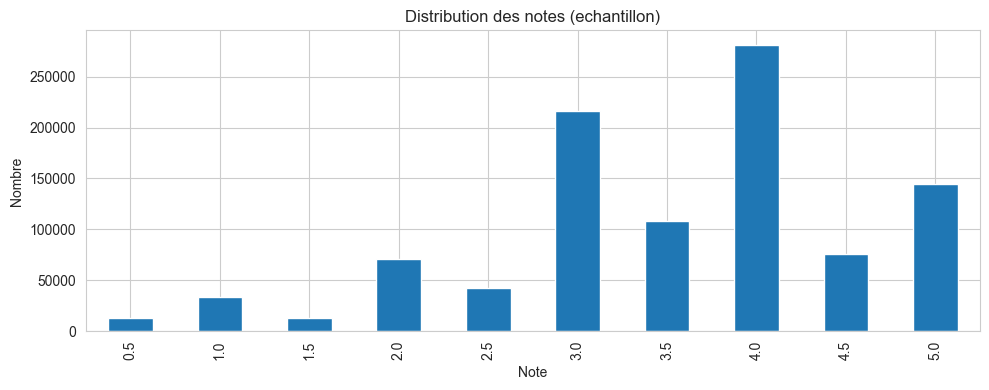


Top 10 des films les plus notes (dans l'echantillon):


,count,title
movieId,,
296,3320,Pulp Fiction (1994)
356,3314,Forrest Gump (1994)
593,3080,"Silence of the Lambs, The (1991)"
318,3061,"Shawshank Redemption, The (1994)"
480,2979,Jurassic Park (1993)
260,2729,Star Wars: Episode IV - A New Hope (1977)
110,2667,Braveheart (1995)
589,2572,Terminator 2: Judgment Day (1991)
2571,2567,"Matrix, The (1999)"



TAGS (echantillon)
Tags uniques: 16,133

Top 10 des tags:
tag
sci-fi               841
atmospheric          794
surreal              595
adapted from:book    594
stylized             591
action               578
comedy               552
twist ending         543
quirky               542
dystopia             499
Name: count, dtype: int64

RESUME
Films totaux: 27,278
Liens IMDb/TMDb: 27,278
Ratings (echantillon): 1,000,000
Tags (echantillon): 100,000

Note moyenne: 3.53
Note mediane: 4.00

Sparsite estimee: 98.94%
(La matrice utilisateur-film est tres creuse)

Les donnees sont pretes pour le preprocessing!


In [1]:
# Exploration rapide des donnees MovieLens 20M
# Version allegee - charge seulement un echantillon

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Bibliotheques importees")

# Chemin vers les donnees
data_path = Path("../data/raw/ml-20m/")
print(f"Chemin des donnees: {data_path}")

# Charger movies (leger, seulement 27k lignes)
print("\n1. Chargement movies.csv...")
movies = pd.read_csv(data_path / "movies.csv")
print(f"   Films: {len(movies):,}")

# Charger links (leger)
print("\n2. Chargement links.csv...")
links = pd.read_csv(data_path / "links.csv")
print(f"   Liens: {len(links):,}")

# Charger SEULEMENT 1 million de ratings (au lieu de 20 millions)
print("\n3. Chargement d'un echantillon de ratings.csv (1M lignes sur 20M)...")
ratings_sample = pd.read_csv(data_path / "ratings.csv", nrows=1000000)
print(f"   Ratings charges: {len(ratings_sample):,}")

# Charger tags (echantillon)
print("\n4. Chargement d'un echantillon de tags.csv...")
tags_sample = pd.read_csv(data_path / "tags.csv", nrows=100000)
print(f"   Tags charges: {len(tags_sample):,}")

print("\nDonnees chargees avec succes!\n")

# MOVIES
print("=" * 60)
print("MOVIES")
print("=" * 60)
print(f"Nombre total de films: {len(movies):,}\n")
print("Premieres lignes:")
display(movies.head())

print("\nGenres les plus frequents:")
all_genres = movies['genres'].str.split('|').explode()
genre_counts = all_genres.value_counts().head(10)
print(genre_counts)

# RATINGS (echantillon)
print("\n" + "=" * 60)
print("RATINGS (echantillon de 1M sur 20M)")
print("=" * 60)
print(f"Utilisateurs uniques: {ratings_sample['userId'].nunique():,}")
print(f"Films notes: {ratings_sample['movieId'].nunique():,}")
print(f"\nStatistiques des notes:")
print(ratings_sample['rating'].describe())

print("\nDistribution des notes:")
print(ratings_sample['rating'].value_counts().sort_index())

plt.figure(figsize=(10, 4))
ratings_sample['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution des notes (echantillon)')
plt.xlabel('Note')
plt.ylabel('Nombre')
plt.tight_layout()
plt.show()

# Films les plus notes dans l'echantillon
print("\nTop 10 des films les plus notes (dans l'echantillon):")
top_movies = ratings_sample.groupby('movieId').size().sort_values(ascending=False).head(10)
top_with_titles = top_movies.to_frame('count').join(movies.set_index('movieId')['title'])
display(top_with_titles)

# TAGS (echantillon)
print("\n" + "=" * 60)
print("TAGS (echantillon)")
print("=" * 60)
print(f"Tags uniques: {tags_sample['tag'].nunique():,}")
print("\nTop 10 des tags:")
print(tags_sample['tag'].value_counts().head(10))

# STATISTIQUES GLOBALES
print("\n" + "=" * 60)
print("RESUME")
print("=" * 60)
print(f"Films totaux: {len(movies):,}")
print(f"Liens IMDb/TMDb: {len(links):,}")
print(f"Ratings (echantillon): {len(ratings_sample):,}")
print(f"Tags (echantillon): {len(tags_sample):,}")
print(f"\nNote moyenne: {ratings_sample['rating'].mean():.2f}")
print(f"Note mediane: {ratings_sample['rating'].median():.2f}")

# Estimation de la sparsite
n_users_sample = ratings_sample['userId'].nunique()
n_movies_sample = ratings_sample['movieId'].nunique()
n_ratings_sample = len(ratings_sample)
possible_ratings = n_users_sample * n_movies_sample
sparsity = (1 - (n_ratings_sample / possible_ratings)) * 100

print(f"\nSparsite estimee: {sparsity:.2f}%")
print("(La matrice utilisateur-film est tres creuse)")

print("\n" + "=" * 60)
print("Les donnees sont pretes pour le preprocessing!")
print("=" * 60)